### Librerias e importaciones

In [1]:
import sys
sys.path.append("../src")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm
import catboost


from preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from data_splitting import train_val_split
from plots import eda_visualizacion_suvs

In [2]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [3]:
data = pd.read_csv('../data/pf_suvs.csv')

In [4]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
       Unnamed: 0    Marca       Modelo     Año                       Versión  \
9197         9197  Citroën  C5 Aircross  2020.0        1.6 Thp Eat6 Feel Pack   
6063         6063     Ford     Ecosport  2009.0                   2.0 Xls 4x2   
5831         5831    Honda         HR-V  2019.0                1.8 Ex 2wd Cvt   
12849       12849     Jeep     Renegade  2021.0             1.8 Longitude At6   
15716       15716     Ford         Kuga  2012.0  2.5 Titanium At 4x4 L (ku05)   

        Color Tipo de combustible  Puertas Transmisión Motor  \
9197     Gris               Nafta      5.0  Automática   1.6   
6063    Negro               Nafta      5.0      Manual   2.0   
5831     Azul               Nafta      5.0  Automática   1.8   
12849  Blanco               Nafta      5.0  Automática   1.8   
15716  Blanco               Nafta      5.0  Automática   2.5   

      Tipo de carrocería Con cámara de retroceso Kilómetros  \
9197                 SUV                     

In [5]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [6]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


*El análisis exploratorio permitió detectar la existencia de valores faltantes en diversas variables descriptivas del vehículo, entre ellas Color, Transmisión, Motor y Con cámara de retroceso. Debido a que estas variables pueden influir significativamente en el valor de mercado de una SUV, se optó por imputar los datos faltantes en lugar de descartar las observaciones correspondientes, preservando así el tamaño de la muestra disponible para entrenamiento.*

*Por otra parte, se observó que gran parte de los atributos del dataset se encuentran representados mediante variables categóricas de tipo texto. Dado que los algoritmos de aprendizaje supervisado utilizados trabajan sobre representaciones numéricas, será necesario transformar dichas variables mediante One-Hot Encoding, generando una codificación binaria que permita incorporar esta información al modelo sin introducir relaciones artificiales entre categorías*

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

- solo hacer limpieza de columnas de suvs 
- pasar de de pesoss a dolar y la borramos  
- col 0 km y usados , 0  1 
- eliminamos lass filas 0 de motor 
- ponemos en puertas todo 5
- pasar con one hot a trsmision 
- borramos unnamed 
- DESCRIPCION -> CLASIFICAR
- TITULO -> BORRAR (es la concatenacion de otros features)

DESPUES DEL SPLIT
- moda de color 
- moda de camara 
- ONE HOT TIPO VENDEDOR 

**Justificacion de desiciones tomadas**


1. ` La variable Unnamed`: 0 actúa únicamente como identificador de cada publicación y no aporta información relevante para la predicción del precio, por lo que fue eliminada.
2. `Cambio de moneda a USD`Para garantizar la comparabilidad entre observaciones y evitar que la moneda introduzca sesgos en los modelos, todos los precios fueron convertidos a dólares utilizando un único tipo de cambio de referencia y se eliminio la columna ya que no aportaba informacion.
3. Se eliminó columnas(features) como `Unnamed`, `Tipo de carroceria`, `Titulo`, `Version`

4. `Imputacion de Puertas`: se observaron valores inconsistentes en la variable Puertas. Dado que el conjunto de datos contiene exclusivamente SUVs, se decidió homogeneizar los valores restantes utilizando cinco puertas como valor por defecto

In [7]:
display(data["Puertas"].value_counts().sort_index())

Puertas
2.0           10
3.0          105
4.0          399
5.0        17731
6.0            3
7.0            2
60252.0        4
Name: count, dtype: int64

5. `Motor`: presentaba únicamente 38 valores faltantes (menos del 0.3% del dataset). Debido a su baja proporción, se optó por eliminar dichas observaciones en lugar de imputarlas para evitar introducir ruido artificial. A su vez , los datos estaban en str. Se pasó a valor numerico

In [8]:
nulos_motor = data["Motor"].isna().sum()
total = len(data)

print(f"Nulos en Motor: {nulos_motor}")
print(f"Total de registros: {total}")
print(f"Porcentaje de nulos: {100*nulos_motor/total:.3f}%")

Nulos en Motor: 38
Total de registros: 18254
Porcentaje de nulos: 0.208%


6. `Kilometros`: Se transformó a valor numérico para garantizar un tratamiento consistente. Además se crea feature ¨0 Km¨ que indica vehiculo nuevo o usado.

7. `Descripcion` : contiene texto libre que no puede ser utilizado directamente por modelos de regresion tradicionales. Se construyó un score basado en palabras clave positivas y negativas asociadas al estado general del vehículo, documentación, mantenimiento y equipamiento. El resultado se transformó en una escala numérica entre 1 y 10.

In [9]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

─── Muestra #0 (índice 17) ───
  Descripción: Buscás, encontrás. Tenés, vendés. Todo en un mismo lugar. Bienvenido a Mamba Cars, donde innovamos una nueva experiencia en la compra y venta de vehiculos en Mar del Plata.Vení a vivir la experiencia Mamba, donde vas encontrar la llave que buscabas para poner en marcha tu próximo viaje
  Palabras positivas encontradas: ninguna
  Palabras negativas encontradas: ninguna

─── Muestra #1 (índice 87) ───
  Descripción: Audi Q5 Quattro 2.0 Turbo 2011 Full con 6ta, Llantas, 4 Levanta Vidrios, Climatizador, Cierre Central, Aire, Dirección, etc. Bienvenidos a Automotores España, líder en servicio y atención al cliente.Venta, permuta y consignación de autos 0 km y usados.Fundada en 1973, nuestra agencia lleva más de 40 años de experiencia en el mercado automotor. Desde la ciudad de Chivilcoy, somos líderes en el mercado local y reconocidos en toda la provincia de Buenos Aires. Contamos además con clientes en todo el país.Con un showroom de 900 mts2, 

**NUEVO DATASET**

In [10]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
                                                   Marca     Modelo     Año  \
17201  <bound method NDFrame.replace of 0            ...    Tiggo 3  2019.0   
7351   <bound method NDFrame.replace of 0            ...    T-Cross  2020.0   
16445  <bound method NDFrame.replace of 0            ...       2008  2025.0   
1533   <bound method NDFrame.replace of 0            ...    Tracker  2019.0   
11538  <bound method NDFrame.replace of 0            ...  C4 Cactus  2022.0   

        Color Tipo de combustible  Puertas Transmisión  Motor  \
17201  Blanco               Nafta      5.0      Manual    1.6   
7351     Gris               Nafta      5.0      Manual    1.6   
16445  Blanco               Nafta      5.0  Automática    1.0   
1533     Gris               Nafta      5.0  Automática    1.8   
11538    Gris               Nafta      5.0      Manual    1.6   

      Con cámara de retroceso  Kilómetros        Precio Tipo de vendedor  0km  \
17201                     

In [11]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Marca,object,0,1
Modelo,str,0,136
Año,float64,0,39
Color,str,389,69
Tipo de combustible,str,0,8
Puertas,float64,0,2
Transmisión,str,11,4
Motor,float64,427,40
Con cámara de retroceso,str,13542,2
Kilómetros,float64,431,2120


**VISUALIZACION DEL EDA HASTA AHORA**

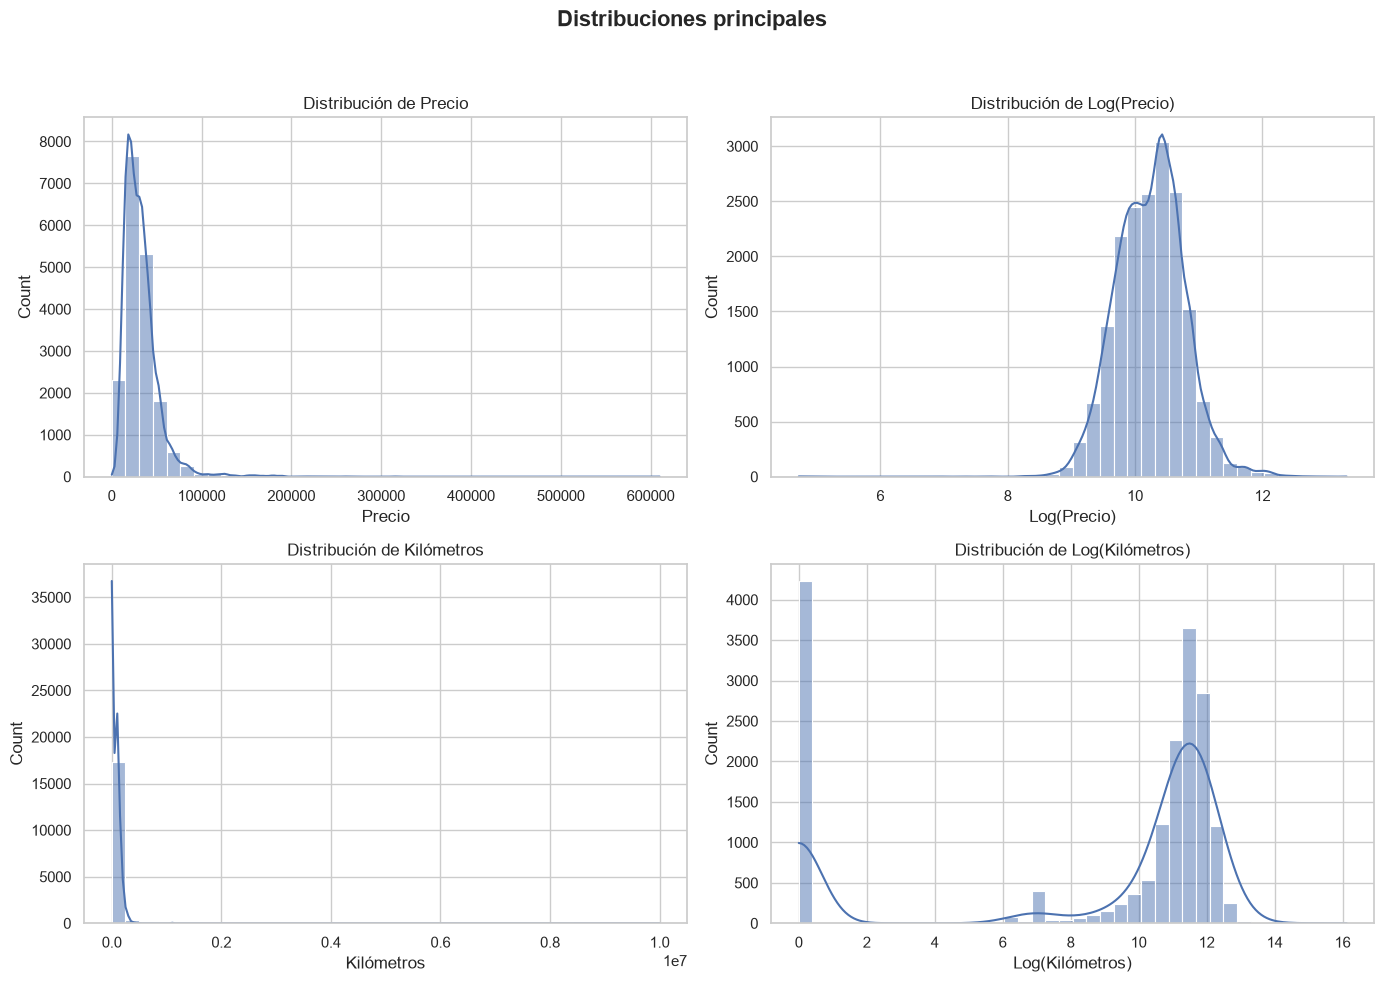

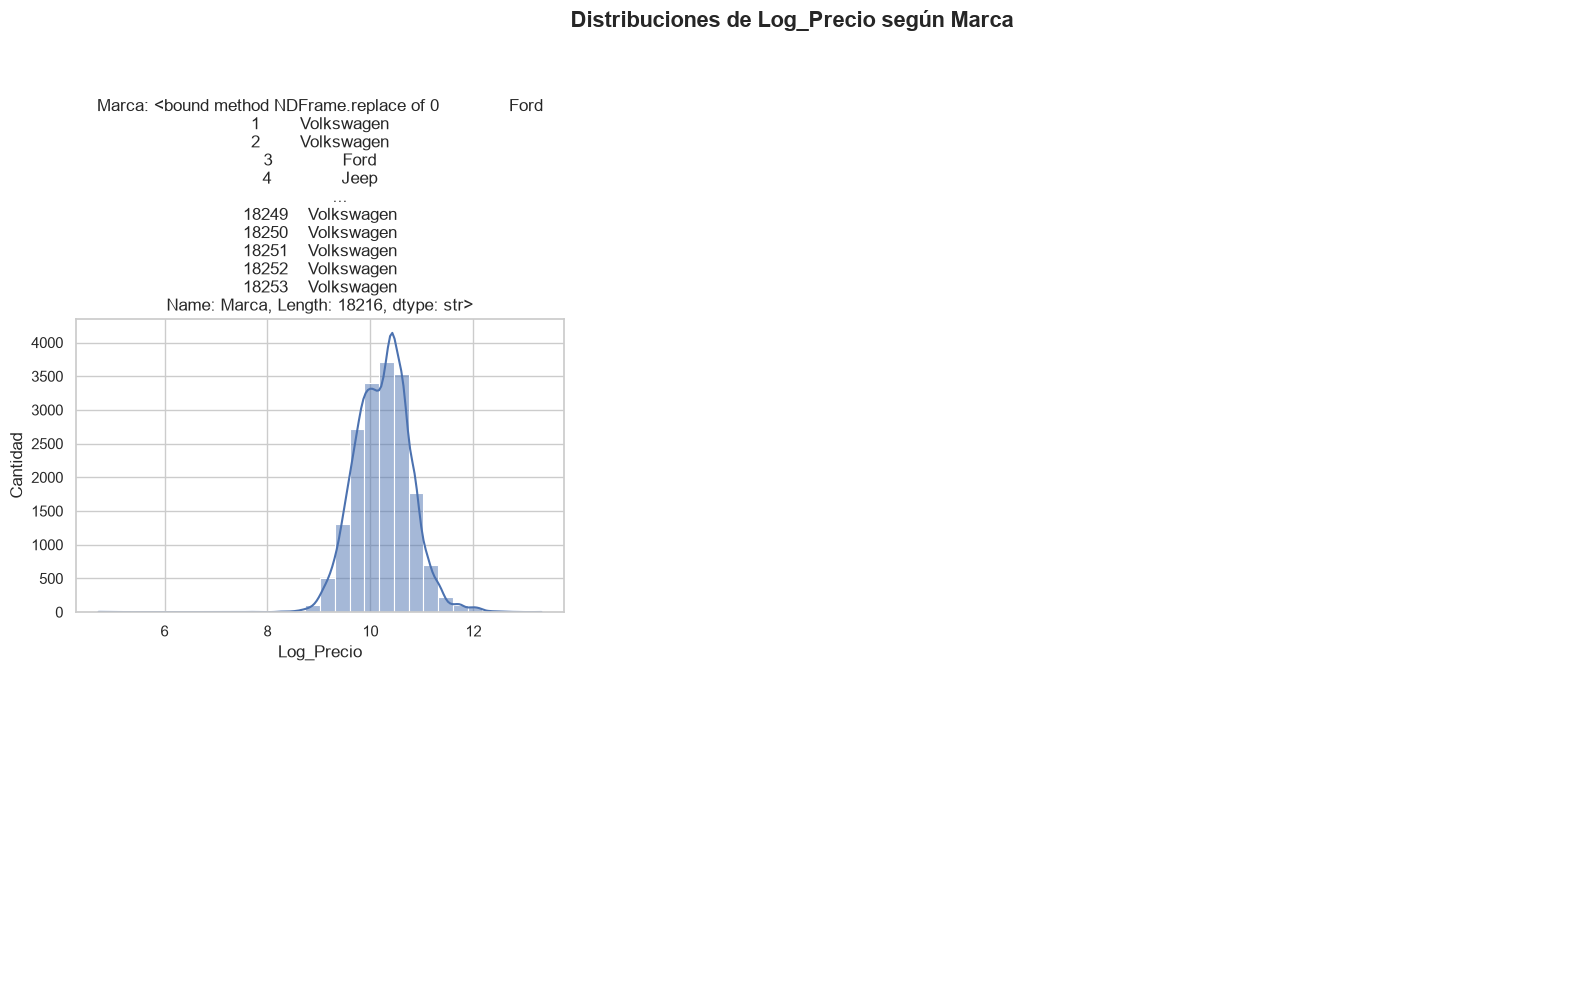

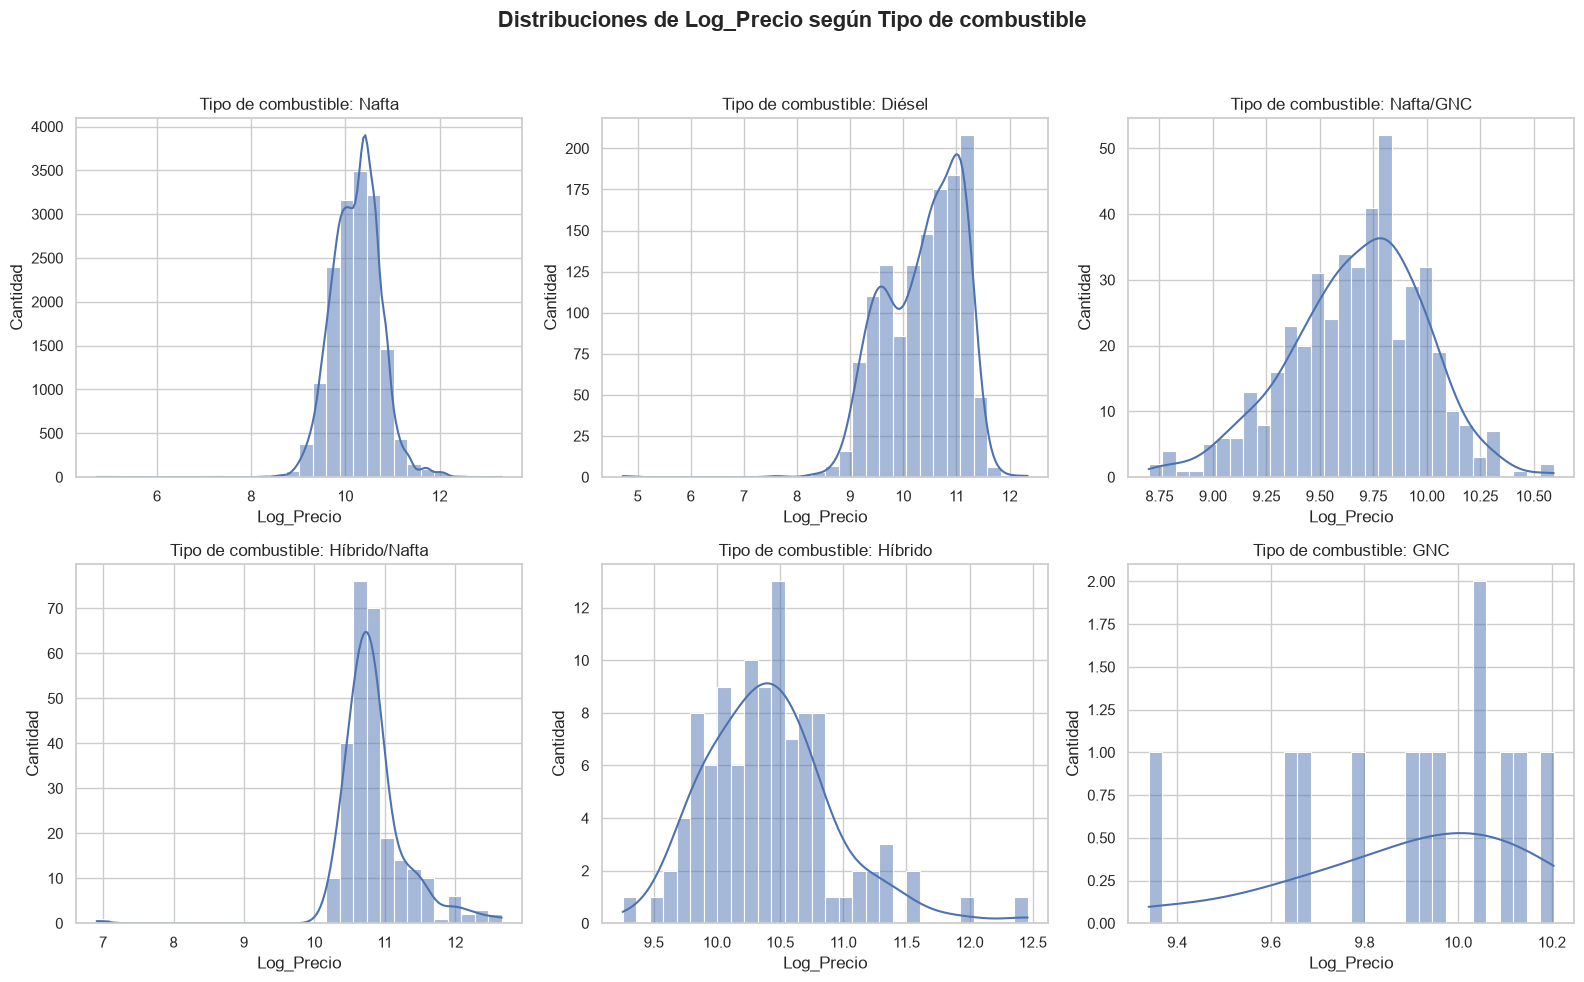

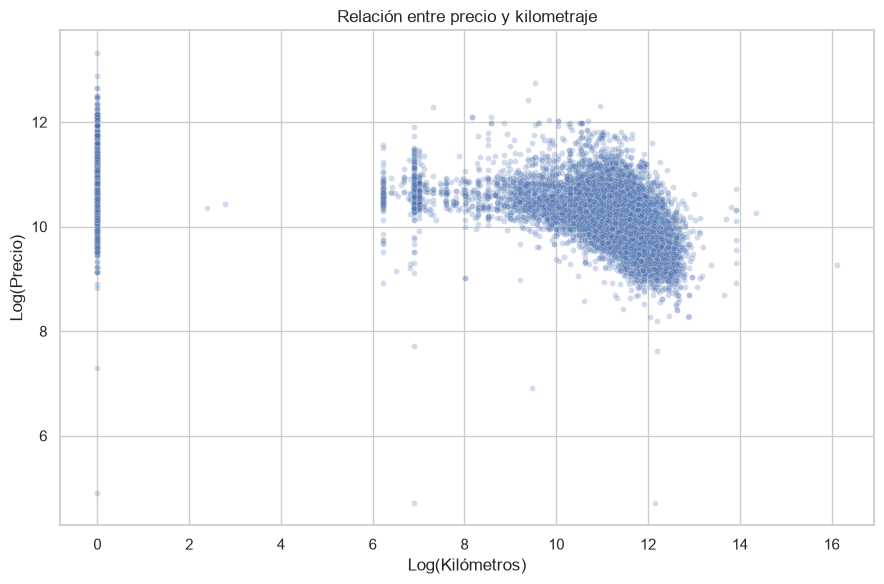

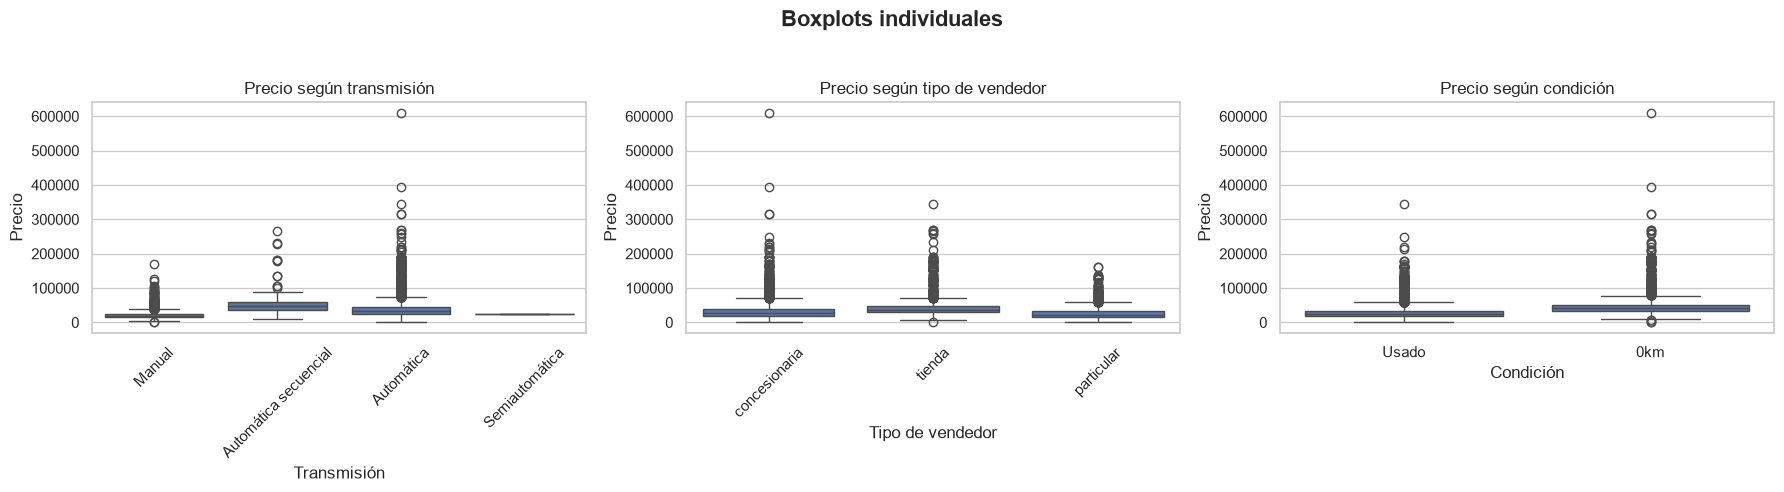

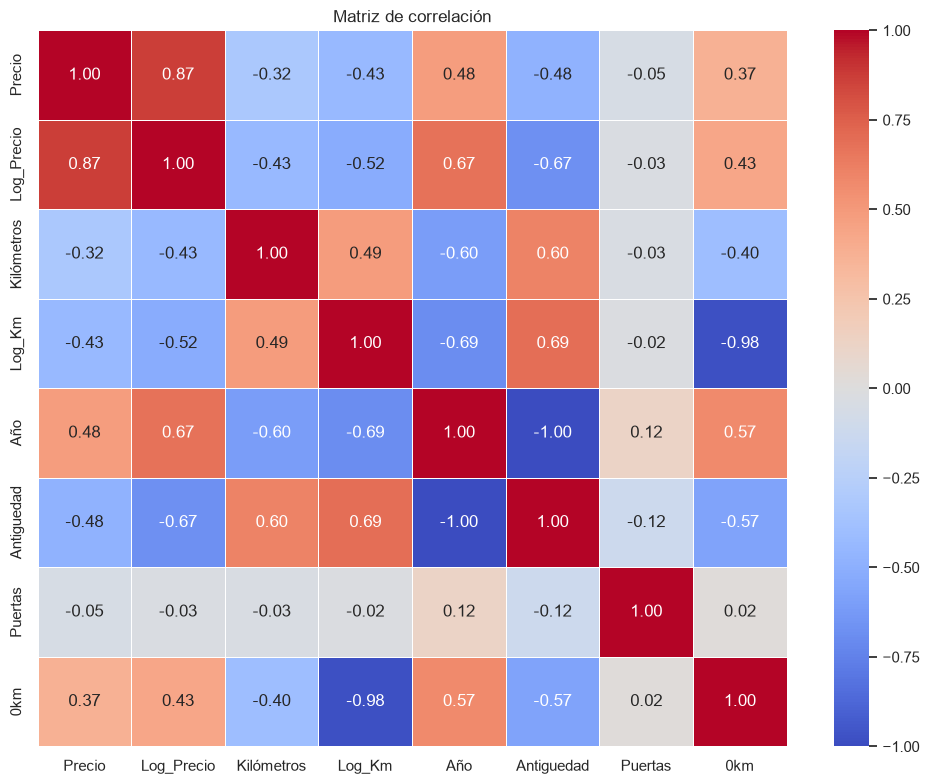

In [12]:
#Plots
eda_visualizacion_suvs(data_pre)

In [13]:
print("TOP 15 MARCAS")
display(data_pre["Marca"].value_counts().head(15))

print("TOP 15 MODELOS")
display(data_pre["Modelo"].value_counts().head(15))

print("TIPOS DE COMBUSTIBLE")
display(data_pre["Tipo de combustible"].value_counts())

print("TRANSMISION")
display(data_pre["Transmisión"].value_counts())

print("TIPO DE VENDEDOR")
display(data_pre["Tipo de vendedor"].value_counts())

TOP 15 MARCAS


Marca
<bound method NDFrame.replace of 0              Ford\n1        Volkswagen\n2        Volkswagen\n3              Ford\n4              Jeep\n            ...    \n18249    Volkswagen\n18250    Volkswagen\n18251    Volkswagen\n18252    Volkswagen\n18253    Volkswagen\nName: Marca, Length: 18216, dtype: str>    18206
Name: count, dtype: int64

TOP 15 MODELOS


Modelo
Ecosport         1568
Tracker          1508
2008             1143
Duster           1047
Compass           916
Kicks             913
Taos              687
Renegade          642
T-Cross           539
Corolla Cross     482
C4 Cactus         448
Nivus             436
Tucson            417
Pulse             341
HR-V              339
Name: count, dtype: int64

TIPOS DE COMBUSTIBLE


Tipo de combustible
Nafta            16026
Diésel            1324
Nafta/GNC          451
Híbrido/Nafta      266
Híbrido            105
GNC                 12
Eléctrico           12
Mild Hybrid         10
Name: count, dtype: int64

TRANSMISION


Transmisión
Automática               12246
Manual                    5828
Automática secuencial      120
Semiautomática               1
Name: count, dtype: int64

TIPO DE VENDEDOR


Tipo de vendedor
concesionaria    8471
particular       5667
tienda           4068
Name: count, dtype: int64

Para terminar con el ***preprocesamiento de datos***, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara"  evitando el data leakage.

In [14]:
train, val = train_val_split(data_pre)

Tamaño conjunto de entrenamiento -> (14564, 14), 
Tamaño conjunto de validación -> (3642, 14)


In [15]:
#Preprocessing post split using the train parameters
train, val = preprocesamiento_post_split(train, val)

In [16]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ['Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
train, val = onehot_encoding(train, val, columnas_oh)

In [17]:
print('Final del preprocesamiento sobre Entrenamiento')
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "nulos": train.isnull().sum(),
    "unicos": train.nunique()
})
summary

Final del preprocesamiento sobre Entrenamiento


,dtype,nulos,unicos
Marca,object,0,1
Modelo,str,0,136
Año,float64,0,39
Color,str,0,63
Puertas,float64,0,2
Motor,float64,348,40
Kilómetros,float64,0,1830
Precio,float64,0,2577
0km,int64,0,2
Score Descripción,int64,0,10


In [18]:
print('Final del preprocesamiento sobre Validación')
summary = pd.DataFrame({
    "dtype": val.dtypes,
    "nulos": val.isnull().sum(),
    "unicos": val.nunique()
})
summary

Final del preprocesamiento sobre Validación


,dtype,nulos,unicos
Marca,object,0,1
Modelo,str,0,114
Año,float64,0,33
Color,str,0,32
Puertas,float64,0,2
Motor,float64,79,34
Kilómetros,float64,0,773
Precio,float64,0,1204
0km,int64,0,2
Score Descripción,int64,0,8


### MODELOS

### Comparison bewtween models

### Final Model